# 5.1 - Introduction to API

Hands-on Lab: Introduction to API

## Tujuan
- Memahami cara kerja API secara umum
- Memahami Pandas sebagai contoh API
- Memahami REST API dan cara menggunakannya lewat contoh NBA API

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dict_ = {'a': [11, 21, 31], 'b': [12, 22, 32]}

# membuat instance DataFrame -> "instance" dalam istilah API
df = pd.DataFrame(dict_)
type(df)

pandas.DataFrame

In [3]:
df.head()

,a,b
0,11,12
1,21,22
2,31,32


In [4]:
df.mean()

a    21.0
b    22.0
dtype: float64

## REST APIs

Menggunakan nba_api untuk mengambil data tim NBA secara nyata lewat HTTP request.

In [5]:
%pip install nba_api --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from nba_api.stats.static import teams

In [7]:
def one_dict(list_dict):
    keys = list_dict[0].keys()
    out_dict = {key: [] for key in keys}
    for dict_ in list_dict:
        for key, value in dict_.items():
            out_dict[key].append(value)
    return out_dict

In [8]:
nba_teams = teams.get_teams()
nba_teams[0:3]

[{'id': 1610612737,
  'full_name': 'Atlanta Hawks',
  'abbreviation': 'ATL',
  'nickname': 'Hawks',
  'city': 'Atlanta',
  'state': 'Georgia',
  'year_founded': 1949},
 {'id': 1610612738,
  'full_name': 'Boston Celtics',
  'abbreviation': 'BOS',
  'nickname': 'Celtics',
  'city': 'Boston',
  'state': 'Massachusetts',
  'year_founded': 1946},
 {'id': 1610612739,
  'full_name': 'Cleveland Cavaliers',
  'abbreviation': 'CLE',
  'nickname': 'Cavaliers',
  'city': 'Cleveland',
  'state': 'Ohio',
  'year_founded': 1970}]

In [9]:
dict_nba_team = one_dict(nba_teams)
df_teams = pd.DataFrame(dict_nba_team)
df_teams.head()

,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966


In [10]:
df_warriors = df_teams[df_teams['nickname'] == 'Warriors']
df_warriors

,id,full_name,abbreviation,nickname,city,state,year_founded
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946


In [11]:
id_warriors = df_warriors[['id']].values[0][0]
id_warriors

np.int64(1610612744)

In [12]:
from nba_api.stats.endpoints import leaguegamefinder

gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=id_warriors)

In [13]:
games = gamefinder.get_data_frames()[0]
games.head()

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
0,52025,1610612744,GSW,Golden State Warriors,0052500211,2026-04-17,GSW @ PHX,L,240,96,...,0.826,12.0,27.0,39.0,22,5,0,20,19,-15.0
1,52025,1610612744,GSW,Golden State Warriors,0052500131,2026-04-15,GSW @ LAC,W,241,126,...,0.619,10.0,26.0,36.0,29,12,3,20,19,5.0
2,22025,1610612744,GSW,Golden State Warriors,0022501199,2026-04-12,GSW @ LAC,L,241,110,...,0.844,16.0,31.0,47.0,24,3,3,9,21,-5.0
3,22025,1610612744,GSW,Golden State Warriors,0022501184,2026-04-10,GSW @ SAC,L,241,118,...,0.929,6.0,30.0,36.0,30,12,4,16,22,-6.0
4,22025,1610612744,GSW,Golden State Warriors,0022501170,2026-04-09,GSW vs. LAL,L,240,103,...,1.000,15.0,23.0,38.0,24,8,2,19,6,-16.0


In [14]:
# lihat variasi MATCHUP yang ada, supaya kita pilih lawan yang benar-benar ada datanya
games['MATCHUP'].unique()

<StringArray>
[  'GSW @ PHX',   'GSW @ LAC',   'GSW @ SAC', 'GSW vs. LAL', 'GSW vs. SAC',
 'GSW vs. HOU', 'GSW vs. CLE', 'GSW vs. SAS',   'GSW @ DEN', 'GSW vs. WAS',
 ...
   'GOS @ PHL',   'GOS @ BOS',   'GOS @ MIA',   'GOS @ ORL', 'GOS vs. NYK',
 'GOS vs. ATL', 'GOS vs. KCK',   'GOS @ KCK',   'GOS @ SDC', 'GOS vs. SDC']
Length: 134, dtype: str

In [15]:
# ambil semua tim lawan dari matchup GSW vs XXX (home) dan GSW @ XXX (away)
home_opponents = set(games[games['MATCHUP'].str.contains('GSW vs.')]['MATCHUP'].str.replace('GSW vs. ', ''))
away_opponents = set(games[games['MATCHUP'].str.contains('GSW @')]['MATCHUP'].str.replace('GSW @ ', ''))

# cari irisan -> tim yang muncul di KEDUA pola
common_opponents = home_opponents & away_opponents
print(common_opponents)

{'SAC', 'NOP', 'MIA', 'NOH', 'MIN', 'SAS', 'VAN', 'POR', 'DET', 'LAC', 'IND', 'SEA', 'CLE', 'TOR', 'PHI', 'BOS', 'NYK', 'BKN', 'PHX', 'UTA', 'CHI', 'CHH', 'MIL', 'LAL', 'DAL', 'ATL', 'ORL', 'NOK', 'DEN', 'CHA', 'WAS', 'HOU', 'MEM', 'OKC', 'NJN'}


In [16]:
games_home = games[games['MATCHUP'] == 'GSW vs. TOR']
games_away = games[games['MATCHUP'] == 'GSW @ TOR']

print("Jumlah home games:", len(games_home))
print("Jumlah away games:", len(games_away))

Jumlah home games: 32
Jumlah away games: 32


In [17]:
print("Rata-rata PLUS_MINUS home:", games_home['PLUS_MINUS'].mean())
print("Rata-rata PLUS_MINUS away:", games_away['PLUS_MINUS'].mean())

Rata-rata PLUS_MINUS home: 2.40625
Rata-rata PLUS_MINUS away: -2.3125


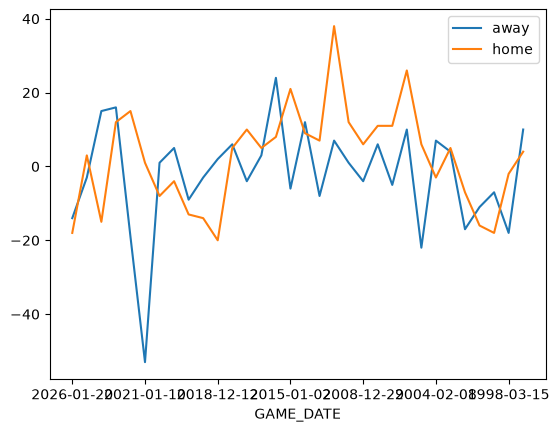

In [18]:
fig, ax = plt.subplots()

games_away.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax)
games_home.plot(x='GAME_DATE', y='PLUS_MINUS', ax=ax)
ax.legend(["away", "home"])
plt.show()

## Quiz

Hitung rata-rata kolom PTS untuk games_home dan games_away.

In [19]:
print("Rata-rata PTS home:", games_home['PTS'].mean())
print("Rata-rata PTS away:", games_away['PTS'].mean())

Rata-rata PTS home: 110.1875
Rata-rata PTS away: 105.3125
